# Análise de um e-commerce de roupas

Projeto desenvolvido no curso de Análise de Dados da EBAC, no módulo de Visualização de Dados com Python.

A base `ecommerce_estatistica.csv` tem produtos de roupa vendidos online (cuecas, jeans, roupa de academia, infantil, etc.) com nota, número de avaliações, desconto, preço, marca, material, gênero e faixa de vendas. Primeiro fiz uma exploração para entender a base e depois escolhi o que valia a pena mostrar em gráfico.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Lendo a base

In [2]:
df = pd.read_csv('../dados/ecommerce_estatistica.csv')
print(df.shape)
df.head()

(295, 24)


,Unnamed: 0,Título,Nota,N_Avaliações,Desconto,Marca,Material,Gênero,Temporada,Review1,...,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
0,1,Kit 10 Cuecas Boxer Lupo Cueca Box Algodão Mas...,4.5,3034.0,18.0,lupo,algodão,Masculino,outono/inverno,As cuecas são boas; porém você percebe na cost...,...,0.814815,0.334178,0.213115,0.378585,463,25,3,10000.0,0.042292,0.176444
1,2,Kit Com 10 Cuecas Boxer Algodão Sem Costura Zo...,4.7,5682.0,20.0,zorba,algodão,Masculino,não definido,O tecido é bom e são confortáveis. Só que a nu...,...,0.888889,0.625937,0.245902,0.322329,838,25,1,50000.0,0.009095,0.176444
2,3,Kit 10 Cuecas Boxer Mash Algodão Cotton Box Or...,4.6,1700.0,22.0,mash,algodão,Masculino,primavera/verão,"As cuecas são boas, porém meu marido usa g e p...",...,0.851852,0.187197,0.278689,0.372617,494,25,7,10000.0,0.010914,0.176444
3,4,Kit 3 Short Jeans Feminino Cintura Alta Barato...,4.4,507.0,9.0,menina linda,jean,Feminino,primavera/verão,Estou encantada com essas peças!.\nOs shorts s...,...,0.777778,0.055751,0.065574,0.201767,509,74,7,1000.0,0.010005,0.025466
4,5,Blusa + Calça Térmica Treino Futebol Criança I...,4.7,58.0,5.0,roupa zero grau,termico unissex,Sem gênero infantil,outono/inverno,"Produto ótimo , mesmo após várias lavagens não...",...,0.888889,0.006280,0.000000,0.114508,669,166,3,100.0,0.002274,0.000910


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 295 entries, 0 to 294
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           295 non-null    int64  
 1   Título               295 non-null    str    
 2   Nota                 295 non-null    float64
 3   N_Avaliações         295 non-null    float64
 4   Desconto             295 non-null    float64
 5   Marca                295 non-null    str    
 6   Material             295 non-null    str    
 7   Gênero               295 non-null    str    
 8   Temporada            295 non-null    str    
 9   Review1              295 non-null    str    
 10  Review2              295 non-null    str    
 11  Review3              295 non-null    str    
 12  Qtd_Vendidos         295 non-null    str    
 13  Preço                295 non-null    float64
 14  Nota_MinMax          295 non-null    float64
 15  N_Avaliações_MinMax  295 non-null    float64
 16  D

In [4]:
df.isnull().sum()

Unnamed: 0             0
Título                 0
Nota                   0
N_Avaliações           0
Desconto               0
Marca                  0
Material               0
Gênero                 0
Temporada              0
Review1                0
Review2                0
Review3                0
Qtd_Vendidos           0
Preço                  0
Nota_MinMax            0
N_Avaliações_MinMax    0
Desconto_MinMax        0
Preço_MinMax           0
Marca_Cod              0
Material_Cod           0
Temporada_Cod          0
Qtd_Vendidos_Cod       0
Marca_Freq             0
Material_Freq          0
dtype: int64

Não tem nenhum valor nulo. A coluna `Unnamed: 0` é só o índice antigo que veio junto no arquivo, então vou tirar.

As colunas com `_MinMax`, `_Cod` e `_Freq` já vieram tratadas na base (normalização, codificação das categorias e frequência de cada marca/material).

In [5]:
df = df.drop(columns='Unnamed: 0')

# conferindo se tem produto repetido
print(f'Linhas duplicadas: {df.duplicated().sum()}')

Linhas duplicadas: 57


Tem 57 linhas exatamente iguais em todas as colunas. Parece o mesmo anúncio coletado mais de uma vez, então removi para não contar o mesmo produto duas vezes.

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(238, 23)

## 2. Explorando as colunas

In [7]:
df[['Nota', 'N_Avaliações', 'Desconto', 'Preço']].describe().round(2)

,Nota,N_Avaliações,Desconto,Preço
count,238.00,238.00,238.00,238.00
mean,4.49,387.74,16.42,126.88
std,0.34,1018.83,10.28,64.79
min,2.30,3.00,5.00,25.63
25%,4.30,16.25,10.00,73.89
50%,4.50,40.50,11.00,125.62
75%,4.70,224.75,22.00,169.90
max,5.00,9077.00,51.00,326.55


O que deu para ver aqui:

- Preço: vai de R\$ 25,63 até R\$ 326,55. Média e mediana bem próximas (R\$ 126,88 e R\$ 125,62).
- Nota: quase tudo entre 4,3 e 4,7. Varia pouco, a menor nota é 2,3.
- N_Avaliações: a média (387) é quase 10 vezes a mediana (40). Ou seja, a maioria dos produtos tem poucas avaliações e uns poucos têm milhares, o que puxa a média para cima.
- Desconto: vai de 5% a 51%, mas metade dos produtos tem até 11%.

In [8]:
df['Qtd_Vendidos'].value_counts()

Qtd_Vendidos
+100      97
+1000     65
+10mil    26
+50       26
+25       17
+50mil     5
+5         2
Name: count, dtype: int64

`Qtd_Vendidos` é texto e representa uma faixa ("+100", "+1000"...), não o número exato. A coluna `Qtd_Vendidos_Cod` guarda o valor mínimo de cada faixa (100, 1000...), então dá para usar ela como ordem: quanto maior, mais o produto vendeu.

In [9]:
df['Marca'].value_counts().head(15)

Marca
lupo               26
stillger           12
stillger jeans     11
adidas             10
zorba               8
menina linda        8
sawary              8
própria             7
keeper              7
mash                6
akorio              6
daze modas          5
colbacho            5
roupa zero grau     3
celi                3
Name: count, dtype: int64

"stillger" e "stillger jeans" parecem ser a mesma marca escrita de dois jeitos, então juntei as duas.

In [10]:
df['Marca'] = df['Marca'].replace('stillger jeans', 'stillger')
df['Marca'].value_counts().head(10)

Marca
lupo            26
stillger        23
adidas          10
zorba            8
menina linda     8
sawary           8
própria          7
keeper           7
mash             6
akorio           6
Name: count, dtype: int64

In [11]:
df['Gênero'].value_counts()

Gênero
Masculino                            103
Feminino                              96
Sem gênero                            13
Meninos                               12
Meninas                                6
Sem gênero infantil                    4
Bebês                                  2
Unissex                                1
roupa para gordinha pluss P ao 52      1
Name: count, dtype: int64

A coluna de gênero tem 9 categorias e algumas têm só 1 ou 2 produtos. Pra ficar mais fácil de visualizar, agrupei em 4 públicos: Masculino, Feminino, Infantil e Sem gênero / Unissex. O produto "roupa para gordinha pluss P ao 52" entrou como Feminino.

In [12]:
mapa_publico = {
    'Masculino': 'Masculino',
    'Feminino': 'Feminino',
    'roupa para gordinha pluss P ao 52': 'Feminino',
    'Meninos': 'Infantil',
    'Meninas': 'Infantil',
    'Sem gênero infantil': 'Infantil',
    'Bebês': 'Infantil',
    'Sem gênero': 'Sem gênero / Unissex',
    'Unissex': 'Sem gênero / Unissex'
}

df['Público'] = df['Gênero'].map(mapa_publico)
df['Público'].value_counts()

Público
Masculino               103
Feminino                 97
Infantil                 24
Sem gênero / Unissex     14
Name: count, dtype: int64

## 3. Perguntas que eu quis responder com os gráficos

1. Como os preços estão distribuídos? (histograma)
2. Produto mais caro tem nota melhor? (dispersão)
3. Quais variáveis numéricas andam juntas? (mapa de calor)
4. Quais marcas têm mais produtos na base? (barras)
5. Pra qual público são os produtos? (pizza)
6. A roupa masculina e a feminina ficam em faixas de preço diferentes? (densidade)
7. Quem vende mais também recebe mais avaliações? (regressão)

### Gráfico 1 - Histograma: distribuição dos preços

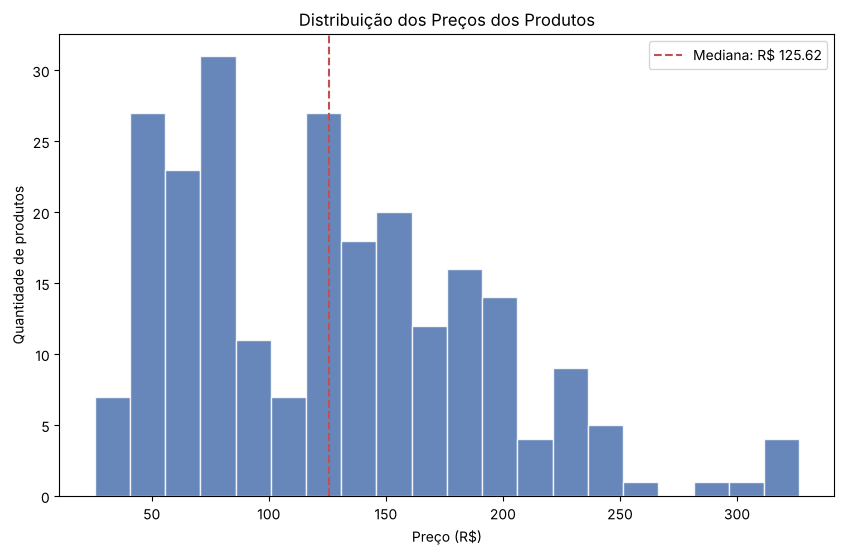

In [13]:
mediana_preco = df['Preço'].median()

plt.figure(figsize=(10, 6))
plt.hist(df['Preço'], bins=20, color='#4c72b0', edgecolor='white', alpha=0.85)
plt.axvline(mediana_preco, color='#c44e52', linestyle='--', label=f'Mediana: R$ {mediana_preco:.2f}')
plt.title('Distribuição dos Preços dos Produtos')
plt.xlabel('Preço (R$)')
plt.ylabel('Quantidade de produtos')
plt.legend()
plt.show()

In [14]:
print(f"Produtos que custam até R$ 200: {(df['Preço'] <= 200).mean():.1%}")

Produtos que custam até R$ 200: 89.1%


Os preços não ficam concentrados em volta de um valor só. Dá para ver dois grupos: um entre R\$ 40 e R\$ 90 e outro entre R\$ 120 e R\$ 200, com um "buraco" entre R\$ 90 e R\$ 120. Quase 90% dos produtos custam até R\$ 200 e bem poucos passam de R\$ 250.

Fiquei curioso com esses dois grupos. Isso aparece de novo no gráfico de densidade mais para baixo.

### Gráfico 2 - Dispersão: preço x nota

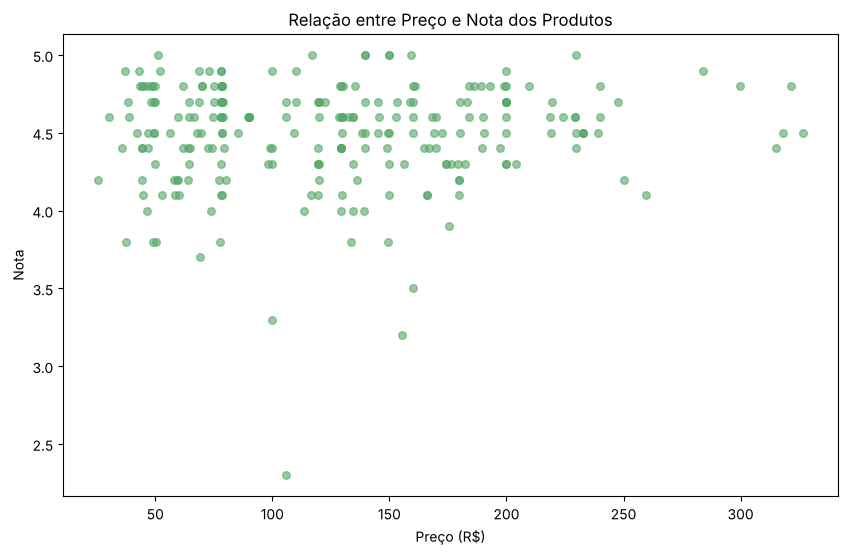

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Preço'], df['Nota'], alpha=0.6, s=30, color='#55a868')
plt.title('Relação entre Preço e Nota dos Produtos')
plt.xlabel('Preço (R$)')
plt.ylabel('Nota')
plt.show()

In [16]:
print(f"Correlação preço x nota: {df['Preço'].corr(df['Nota']):.2f}")

Correlação preço x nota: 0.07


In [17]:
print(f"Produtos com nota 4 ou mais: {(df['Nota'] >= 4).mean():.1%}")

Produtos com nota 4 ou mais: 95.0%


In [18]:
# as notas mais baixas
df.nsmallest(4, 'Nota')[['Título', 'Nota', 'N_Avaliações', 'Preço']]

,Título,Nota,N_Avaliações,Preço
237,Kit 4 Bermudas Plusais Estampada Caminhada Ult...,2.3,4.0,105.93
129,Kit 10 Peças Roupa Infantil Menino 5 Shorts + ...,3.2,5.0,155.31
202,Moletom Infantil Calça Masculina Juvenil Kit 3...,3.3,24.0,99.93
99,Kit 03 Bermudas Jeans Vira Lata Original,3.5,4.0,159.91


Não tem padrão nenhum. A correlação deu 0,07, praticamente zero. Produto barato e produto caro recebem nota parecida, e 95% dos produtos têm nota 4 ou mais.

Das 4 notas mais baixas, 3 são de produtos com só 4 ou 5 avaliações, então uma ou duas pessoas insatisfeitas já derrubam a média. Como a nota varia muito pouco na base, fica difícil ela ter relação forte com qualquer outra coluna.

### Gráfico 3 - Mapa de calor: correlação entre as variáveis numéricas

Deixei de fora `Marca_Cod`, `Material_Cod` e `Temporada_Cod` porque são categorias transformadas em número e a ordem dos códigos não significa nada (a marca de código 400 não é "maior" que a de código 200). As colunas `_MinMax` também ficaram de fora porque são as mesmas variáveis em outra escala, a correlação daria igual.

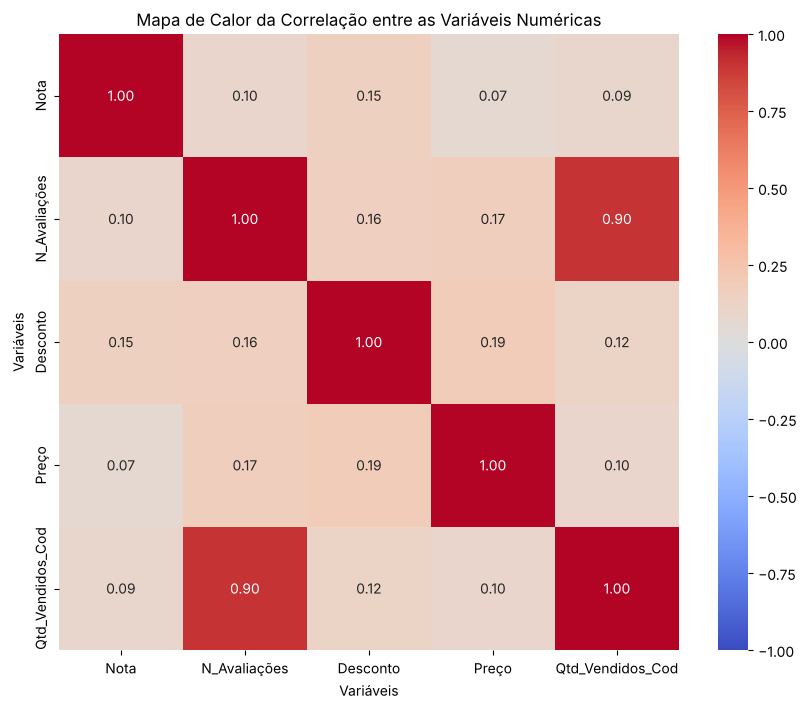

In [19]:
colunas_corr = ['Nota', 'N_Avaliações', 'Desconto', 'Preço', 'Qtd_Vendidos_Cod']
corr = df[colunas_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Calor da Correlação entre as Variáveis Numéricas')
plt.xlabel('Variáveis')
plt.ylabel('Variáveis')
plt.show()

O único par com correlação forte é N_Avaliações x Qtd_Vendidos_Cod (r = 0,90). Faz sentido: quanto mais gente compra, mais gente avalia.

Todo o resto ficou entre 0,07 e 0,19, que é correlação fraca. O maior desses é Desconto x Preço (0,19), produto mais caro tende a ter um pouco mais de desconto, mas bem pouco. Correlação baixa aqui não quer dizer que preço ou desconto não importam para venda, só que não existe uma relação em linha reta entre eles nessa base.

### Gráfico 4 - Barras: marcas com mais produtos

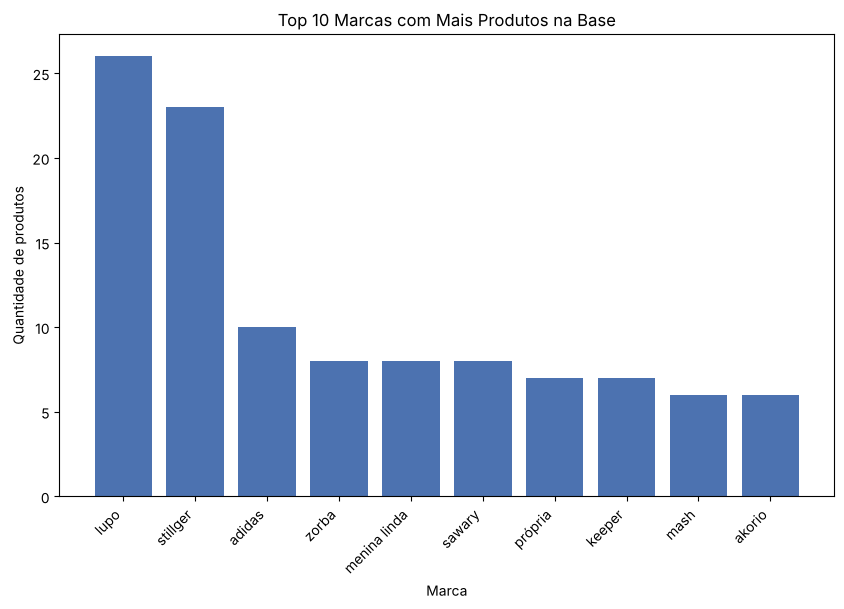

In [20]:
top_marcas = df['Marca'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_marcas.index, top_marcas.values, color='#4c72b0')
plt.title('Top 10 Marcas com Mais Produtos na Base')
plt.xlabel('Marca')
plt.ylabel('Quantidade de produtos')
plt.xticks(rotation=45, ha='right')
plt.show()

In [21]:
# a lupo aparece muito, quis ver também quem concentra as avaliações
aval_marca = df.groupby('Marca')['N_Avaliações'].sum().sort_values(ascending=False)
pd.DataFrame({
    'avaliações': aval_marca,
    '% do total': (aval_marca / aval_marca.sum() * 100).round(1)
}).head(5)

,avaliações,% do total
Marca,,
lupo,27739.0,30.1
zorba,20307.0,22.0
zaroc,9077.0,9.8
mash,4414.0,4.8
almix,4293.0,4.7


Lupo e Stillger dominam a base, com 26 e 23 produtos. Depois vem a Adidas com 10 e o resto fica entre 6 e 8. "própria" parece ser produto de marca própria do vendedor, não uma marca de verdade.

O que mais chamou atenção foi nas avaliações: a Lupo lidera com 30% do total, mas a Zorba vem logo atrás com 22% tendo só 8 produtos (todos kits de cueca). Juntas, as duas têm mais da metade de todas as avaliações da base. Ou seja, poucos anúncios concentram boa parte das vendas.

### Gráfico 5 - Pizza: produtos por público

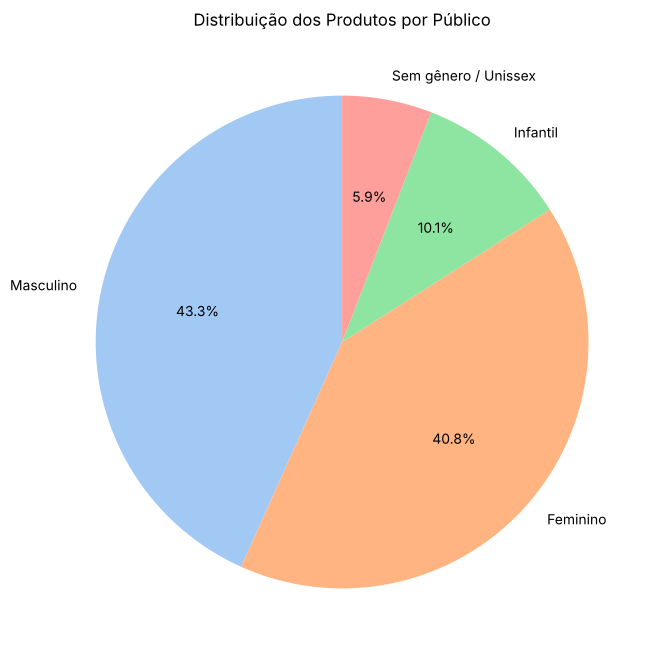

In [22]:
publico = df['Público'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(publico.values, labels=publico.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('pastel'))
plt.title('Distribuição dos Produtos por Público')
plt.show()

A maior parte é roupa adulta e bem equilibrada entre masculino (43,3%) e feminino (40,8%). Infantil fica com 10,1% e sem gênero/unissex com 5,9%.

### Gráfico 6 - Densidade: preço da roupa masculina x feminina

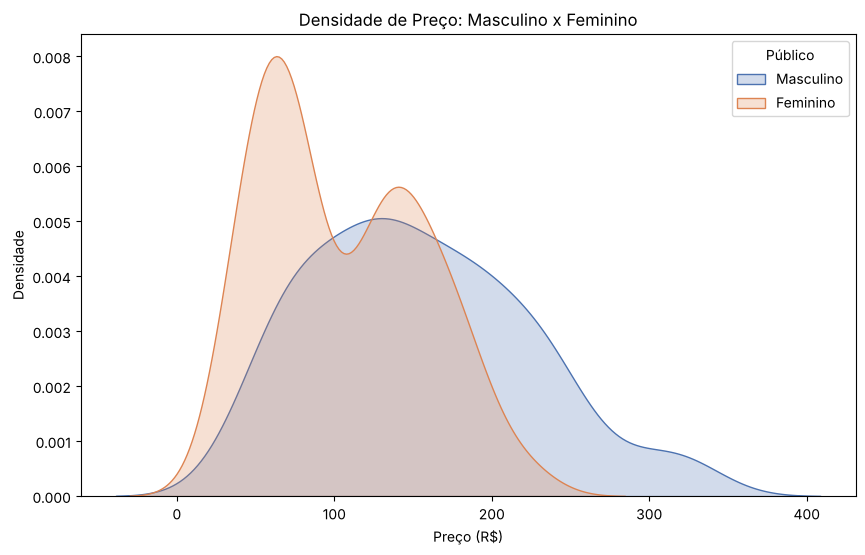

In [23]:
preco_masc = df[df['Público'] == 'Masculino']['Preço']
preco_fem = df[df['Público'] == 'Feminino']['Preço']

plt.figure(figsize=(10, 6))
sns.kdeplot(preco_masc, fill=True, color='#4c72b0', label='Masculino')
sns.kdeplot(preco_fem, fill=True, color='#dd8452', label='Feminino')
plt.title('Densidade de Preço: Masculino x Feminino')
plt.xlabel('Preço (R$)')
plt.ylabel('Densidade')
plt.legend(title='Público')
plt.show()

In [24]:
df[df['Público'].isin(['Masculino', 'Feminino'])].groupby('Público')['Preço'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Público,,,,,,,,
Feminino,97.0,105.08,50.45,30.40,64.09,80.36,145.31,223.99
Masculino,103.0,154.39,69.17,43.38,99.94,149.43,199.94,326.55


In [25]:
# quem está no grupo mais barato do histograma (R$ 40 a R$ 90)
faixa_barata = df[(df['Preço'] >= 40) & (df['Preço'] < 90)]
faixa_barata['Público'].value_counts(normalize=True).round(2)

Público
Feminino                0.52
Masculino               0.29
Infantil                0.13
Sem gênero / Unissex    0.06
Name: proportion, dtype: float64

Aqui ficou mais claro o que apareceu no histograma. A roupa feminina tem um pico forte perto de R\$ 65 e um segundo, menor, perto de R\$ 140, com mediana de R\$ 80,36. A masculina é mais espalhada, com pico perto de R\$ 130 e chegando até R\$ 326, mediana de R\$ 149,43.

Na faixa de R\$ 40 a R\$ 90 mais da metade dos produtos é feminino, então o grupo mais barato do histograma é puxado pela roupa feminina. Pode ter a ver com o tipo de produto (muito kit de cueca no masculino, short e legging no feminino), mas isso é hipótese, não testei aqui.

Obs: a curva começa um pouco antes do zero, mas é só a suavização do KDE. O menor preço real é R\$ 30,40 no feminino e R\$ 43,38 no masculino.

### Gráfico 7 - Regressão: faixa de vendas x número de avaliações

No mapa de calor essas duas foram as que mais andaram juntas. O problema é que os valores vão de 5 até 50 mil, então no gráfico normal quase todos os pontos ficam espremidos no canto. Por isso usei escala logarítmica (log10) nos dois eixos e coloquei os valores originais nos rótulos para facilitar a leitura. Também usei um `x_jitter` pequeno porque as vendas são faixas e os pontos ficavam empilhados uns em cima dos outros.

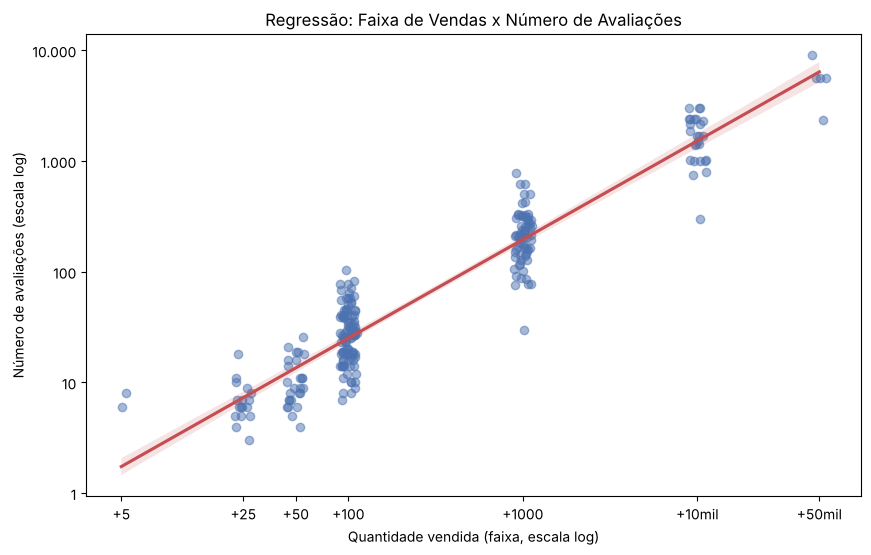

In [26]:
df['log_vendidos'] = np.log10(df['Qtd_Vendidos_Cod'])
df['log_avaliacoes'] = np.log10(df['N_Avaliações'])

plt.figure(figsize=(10, 6))
sns.regplot(x='log_vendidos', y='log_avaliacoes', data=df, x_jitter=0.05, color='#c44e52',
            scatter_kws={'alpha': 0.5, 'color': '#4c72b0'})

faixas = [5, 25, 50, 100, 1000, 10000, 50000]
plt.xticks(np.log10(faixas), ['+5', '+25', '+50', '+100', '+1000', '+10mil', '+50mil'])
plt.yticks([0, 1, 2, 3, 4], ['1', '10', '100', '1.000', '10.000'])

plt.title('Regressão: Faixa de Vendas x Número de Avaliações')
plt.xlabel('Quantidade vendida (faixa, escala log)')
plt.ylabel('Número de avaliações (escala log)')
plt.show()

In [27]:
print(f"Correlação vendas x avaliações (log): {df['log_vendidos'].corr(df['log_avaliacoes']):.2f}")

Correlação vendas x avaliações (log): 0.95


In [28]:
# mediana de avaliações em cada faixa de vendas
df.groupby('Qtd_Vendidos_Cod')['N_Avaliações'].median()

Qtd_Vendidos_Cod
5.0           7.0
25.0          6.0
50.0          9.0
100.0        27.0
1000.0      212.0
10000.0    1688.0
50000.0    5688.0
Name: N_Avaliações, dtype: float64

Com a escala log a relação fica quase uma linha reta (r = 0,95). A mediana de avaliações sobe junto com cada faixa: 27 na +100, 212 na +1000, 1.688 na +10mil e 5.688 na +50mil.

Isso não é causa e efeito, a avaliação vem depois da venda. Mas mostra que o número de avaliações funciona bem como termômetro de vendas, o que ajuda, já que a base só tem a quantidade vendida em faixa e não o número exato.

## 4. Conclusão

- Os preços se dividem em dois grupos (R\$ 40 a 90 e R\$ 120 a 200), e a diferença entre roupa feminina (mediana R\$ 80) e masculina (mediana R\$ 149) explica boa parte disso.
- A nota quase não varia (95% dos produtos com 4 ou mais) e não tem relação com o preço.
- Venda e avaliação andam juntas (r = 0,90 normal e 0,95 em log). Preço, desconto e nota têm correlação fraca com tudo.
- Poucas marcas concentram a base: Lupo e Stillger são 1 em cada 5 produtos, e Lupo e Zorba juntas têm mais da metade das avaliações.

Numa próxima análise eu tiraria o tipo de produto do título (cueca, jeans, legging, short...) para ver se ele explica melhor a diferença de preço entre masculino e feminino.